# CATF Training Tutorial 

This tutorial demonstrates how to train the CATF (Context-Aware Time-Series Forecasting) model on the Electricity Transformer Hourly (ETTh1) dataset using a manager–worker architecture.

We walk through:
1. Environment Setup
2. Configuration Loading
3. Data Preparation
4. Model Construction
5. Training and Evaluation
6. Results


### 1. Environment Setup

**Import required libraries:**

In [9]:
# Standard library imports
import os
import sys
import argparse
import yaml
import numpy as np
from datetime import datetime
import logging
from pathlib import Path

# Deep learning and scientific computing
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam, Optimizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Add the project root to Path:**

In [10]:
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

**Import entire cap module:**

In [11]:
import cap
from cap import *

### 2. Configuration Loading

In [12]:
# Load Configuration
config_path = '../cap/configs/cap/ETTh1/et_cap_fed.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Print configuration
print("Configuration:")
print(f"Dataset: {config['data']['path']}")
for i, worker in enumerate(config['models']['workers']):
    print(f"Workers: {worker['count']} x {worker['type']}")
print(f"Training: {config['training']['epochs']} epochs")

Configuration:
Dataset: dataset/long_term_forecast/ETT-small/ETTh1.csv
Workers: 3 x fedformer
Training: 30 epochs


In [13]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 3. Data Preparation

We use the `get_dataloaders` function to split and normalize the dataset.

In [14]:
train_loader, val_loader, test_loader = cap.get_dataloaders(
            path=str(project_root / config['data']['path']),
            batch_size=config['data']['batch_size'],
            shuffle=True,
            train_size=config['data']['train_size'],
            valid_size=config['data']['valid_size'],
            test_size=config['data']['test_size'],
            normalization=config['data']['normalization'],
            seq_len=config['data']['seq_len'],
            pred_len=config['data']['pred_len']
        )

**Define input/output dimensions:**

In [15]:
# Get input dimensions from first batch
for batch in train_loader:
    inputs, targets = batch
    input_dim = inputs.shape[-1]
    output_dim = targets.shape[-1]
    seq_len = inputs.shape[1]
    pred_len = targets.shape[1]
    break

print(f"Input dimension: {input_dim}")
print(f"Output dimension: {output_dim}")
print(f"Sequence length: {seq_len}")
print(f"Prediction length: {pred_len}")


Input dimension: 7
Output dimension: 1
Sequence length: 96
Prediction length: 96


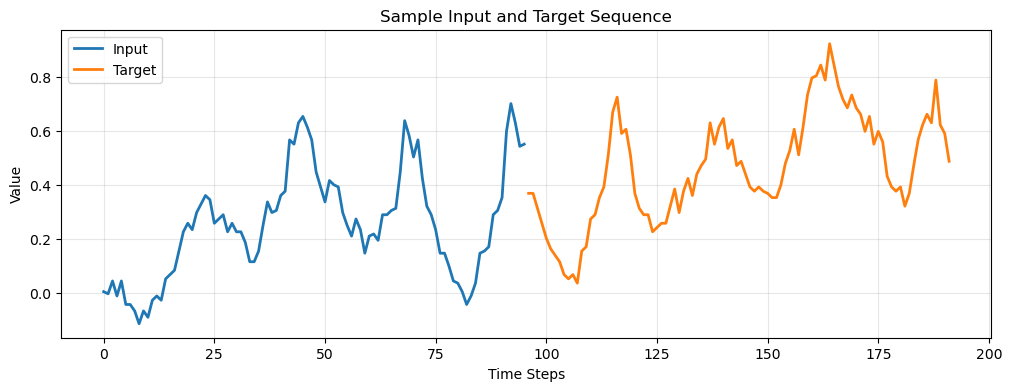

In [16]:
# Visualize a sample from the dataset
plt.figure(figsize=(12, 4))

# Get input and target data
input_data = inputs[0, :, 0].numpy()
target_data = targets[0, :, 0].numpy()

# Calculate global min and max for consistent y-axis
y_min = min(input_data.min(), target_data.min())
y_max = max(input_data.max(), target_data.max())

# Add some padding to the y-axis
y_range = y_max - y_min
y_min -= y_range * 0.05
y_max += y_range * 0.05

# Plot with consistent y-axis
plt.plot(input_data, label='Input', linewidth=2)
plt.plot(range(seq_len, seq_len + pred_len), target_data, label='Target', linewidth=2)
plt.title('Sample Input and Target Sequence')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.ylim(y_min, y_max)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4. Model Construction

Create function `create_worker_configs` to load worker configuration from the config files.

In [10]:
def create_worker_configs(config, input_dim, output_dim, seq_len, pred_len):
    """
    Create worker configurations from the config file, supporting multiple instances.
    
    Args:
        config: Configuration dictionary
        input_dim: Input dimension from data
        output_dim: Output dimension from data
        seq_len: Sequence length from data
        pred_len: Prediction length from data
        
    Returns:
        Tuple of (List of worker configurations, List of worker names)
    """
    worker_configs = []
    worker_names = []
    
    for worker_config in config['models']['workers']:
        # Base configuration
        base_config = {
            'input_dim': input_dim,
            'output_dim': output_dim,
            'seq_len': seq_len,
            'pred_len': pred_len,
        }
        
        # Add worker-specific parameters
        if 'count' in worker_config:
            for i in range(worker_config['count']):
                worker_configs.append({
                    'type': worker_config['type'],
                    'hidden_dim': worker_config['hidden_dim'],
                    'num_layers': worker_config['num_layers'],
                    'dropout': worker_config['dropout'],
                    **base_config
                })
        else:
            worker_configs.append({
                'type': worker_config['type'],
                'hidden_dim': worker_config['hidden_dim'],
                'num_layers': worker_config['num_layers'],
                'dropout': worker_config['dropout'],
                **base_config
            })
    
    return worker_configs

**Create Worker Pool:**

In [11]:
print("  Creating worker configurations...")
worker_configs = create_worker_configs(config, input_dim, output_dim, seq_len, pred_len)

  Creating worker configurations...


**Create Worker Models:**

In [12]:
print("  Creating models...")
worker_models = cap.catf.create_worker_pool(worker_configs, cap.catf.available_models())

  Creating models...


In [13]:
print(f" Created {len(worker_models)} worker models:")
for i, worker in enumerate(worker_models):
    model_name = type(worker.model).__name__
    print(f"   Worker {i+1}: {model_name}")

 Created 3 worker models:
   Worker 1: FEDformer
   Worker 2: FEDformer
   Worker 3: FEDformer


**Create Manager Model:**

In [14]:
manager_config = config['models']['manager']
manager_model = cap.catf.ManagerModel(
    input_dim=input_dim,
    worker_count=len(worker_models),
    d_model=manager_config['d_model'],
    n_heads=manager_config['n_heads'],
    d_ff=manager_config['d_ff'],
    num_layers=manager_config['num_layers'],
    dropout=manager_config['dropout']
)

### 5. Training and Evaluation

**Train the CATF Model:**

In [15]:
# Create trainer
print(" Creating trainer...")
trainer = cap.catf_trainer.CATFTrainer(
    manager_model=manager_model,
    worker_models=worker_models,
    criterion=nn.MSELoss(),
    device=device,
    manager_lr=config['training']['manager_lr'],
    worker_lr=config['training']['worker_lr'],
    log_dir=config['logging']['log_dir'],
    clip_value=config['training']['clip_value'],
    worker_update_steps=config['training']['worker_update_steps'],
    use_multi_gpu=False,  # Disable multi-GPU training to avoid NCCL errors
    distributed=False  # Use DataParallel instead of DDP for now
)

 Creating trainer...
 Using single device training on cuda
 Compatible models:
   Worker 0: FEDformer (new interface)
   Worker 1: FEDformer (new interface)
   Worker 2: FEDformer (new interface)
 GPU Information:
   Total GPUs: 2
   Current device: cuda
   Multi-GPU enabled: False
   Distributed training: False
   GPU 0: NVIDIA GeForce RTX 4090 (23.5 GB)
   GPU 1: NVIDIA GeForce RTX 4090 (23.5 GB)


In [16]:
print(" Starting training...")
history = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=config['training']['epochs'],
    checkpoint_dir=config['logging']['checkpoint_dir'],
    early_stopping_patience=config['training']['patience'],  # No early stopping for quick test
    plot_metrics=config['logging']['plot_metrics'],
    #plot_metrics=True        
    pre_training_epochs=config['training']['pre_training_epochs']
)

 Starting training...

Epoch 1/30
Current learning rates - Manager: 0.000010, Worker: 0.000100

  Batch 0: Worker Loss = 5.2651, Manager Loss = 0.00585291
    Debug - Loss Components:
      KL Div: 0.221676, Entropy: 0.915095
      Diversity: 0.333333, Wasserstein: 0.000363
      Weights: entropy=0.010, diversity=0.001
      Wasserstein (primary): 0.000363
  Batch 32: Worker Loss = 2.4282, Manager Loss = 0.00411642
  Batch 64: Worker Loss = 2.4925, Manager Loss = 0.00407458
  Batch 96: Worker Loss = 1.4172, Manager Loss = 0.00398739
  Batch 128: Worker Loss = 1.7677, Manager Loss = 0.00398973
  Batch 160: Worker Loss = 2.0291, Manager Loss = 0.00392808
  Batch 192: Worker Loss = 2.1099, Manager Loss = 0.00396587
  Batch 224: Worker Loss = 1.3463, Manager Loss = 0.00404862
  Batch 256: Worker Loss = 1.5577, Manager Loss = 0.00389206
  Batch 288: Worker Loss = 3.0624, Manager Loss = 0.00390178
  Batch 320: Worker Loss = 1.6665, Manager Loss = 0.00383251
  Batch 352: Worker Loss = 2.0881,

**Evaluation:**

In [17]:
# Evaluation
print(" Evaluating on test set...")
test_loss = trainer.validate(test_loader)

 Evaluating on test set...


### 6. Results

In [34]:
print("\n Training completed!")
print(f"   Final training loss: {history['train_losses'][-1]:.4f}")
print(f"   Final validation loss: {history['val_losses'][-1]:.4f}")
print(f"   Test loss: {test_loss:.4f}")
print(f"   Best validation loss: {min(history['val_losses']):.4f}")


 Training completed!
   Final training loss: 0.0903
   Final validation loss: 0.0868
   Test loss: 0.0884
   Best validation loss: 0.0868


In [35]:
# Worker selection analysis
final_selections = history['worker_selections'][-1]
print("\n Final worker selection rates:")
for i, rate in enumerate(final_selections):
    print(f"   Worker {i}: {rate:.3f}")

print("\n CATF training completed successfully!")


 Final worker selection rates:
   Worker 0: 0.334
   Worker 1: 0.342
   Worker 2: 0.324

 CATF training completed successfully!
